# Import Libraries

In [124]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [125]:
# Load Excel Dataset
df = pd.read_excel(r"C:\Users\Dinesh more\Downloads\project Data new.xlsx")

In [126]:
# Display First 5 Rows
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [127]:
# Display Complete Dataset
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [128]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [129]:
# Check Missing Values
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [130]:
# Create State Data Frame
#Unique geographic entities are converted into a structured separate DataFrame table (State = pd.DataFrame(...)) so they can later be exported or referenced as a dedicated entity/dimension table.

State = df["State"].unique()

State = pd.DataFrame(State)

State



,0
0,Maharashtra
1,Andhra Pradesh
2,Uttar Pradesh
3,Karnataka
4,Gujarat
5,Himachal Pradesh
6,Delhi
7,Madhya Pradesh
8,Jharkhand
9,Kerala


# DC

In [131]:
#Rename Occupation column
#To make business column headers more descriptive and consistent for modeling, we use .rename() with columns={'Occupation': 'Sector'} and set inplace=True to directly modify the original DataFrame without creating a copy.

df.rename(columns={"Occupation":"Sector"},inplace=True)

In [132]:
# Map Numeric Marital Status (0 to Single, 1 to Married)
df["Marital_Status"] = df["Marital_Status"].replace({1: "Married", 0: "Single"})

In [133]:
#Remove Unnecessary columns
df.drop(["unnamed1", "Status"], axis=1, inplace=True)

# DV

In [134]:
#Display First 5 Rows After Cleaning
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


In [135]:
# Check Unique Age Groups
df["Age Group"].unique()

array(['26-35', '0-17', '18-25', '55+', '46-50', '51-55', '36-45'],
      dtype=object)

# Age Group Wise Gender Chart

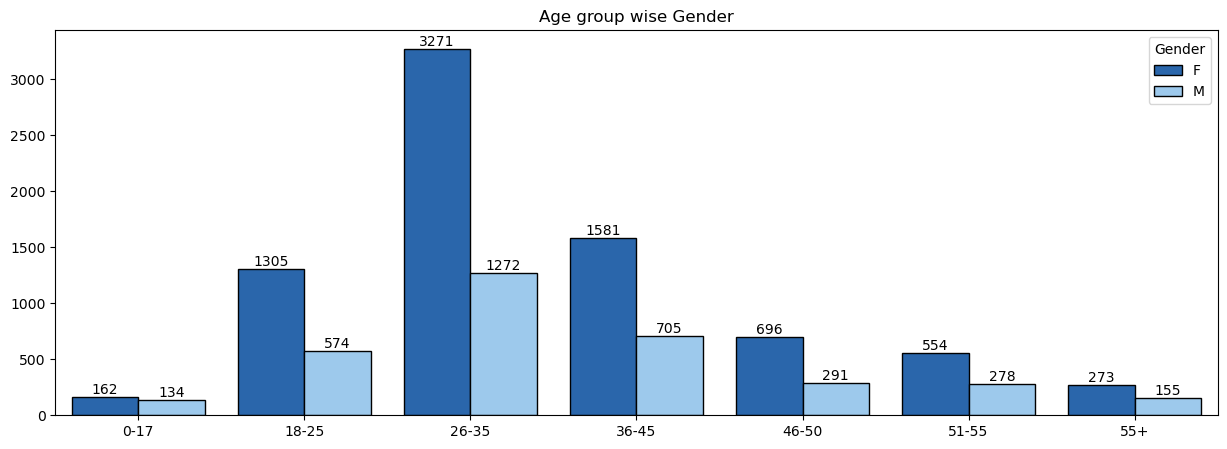

In [136]:
plt.figure(figsize=(15,5))

age_order = ["0-17",'18-25','26-35','36-45','46-50','51-55','55+']

A1=sns.countplot(
    x="Age Group",
    data=df,
    hue="Gender",
    palette=["#1565C0","#90CAF9"],
    edgecolor="black",
    order=age_order
)

plt.title("Age group wise Gender")

plt.xlabel("")

plt.ylabel("")

for y in A1.containers:
    A1.bar_label(y)

plt.show()

# Sector wise Total Orders

In [137]:
T1 = df.groupby("Sector", as_index=False)["Orders"].sum()

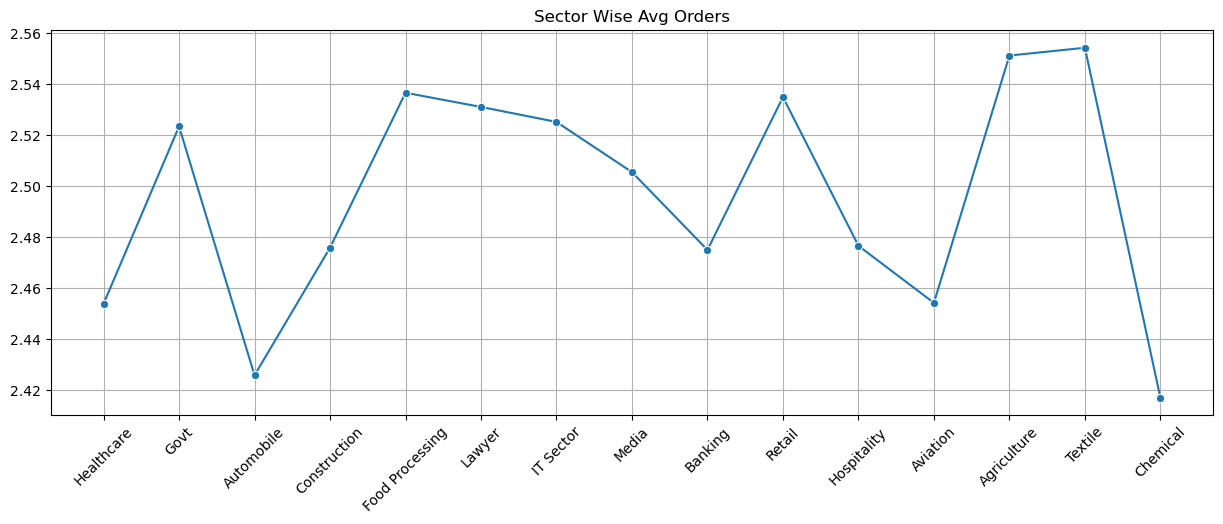

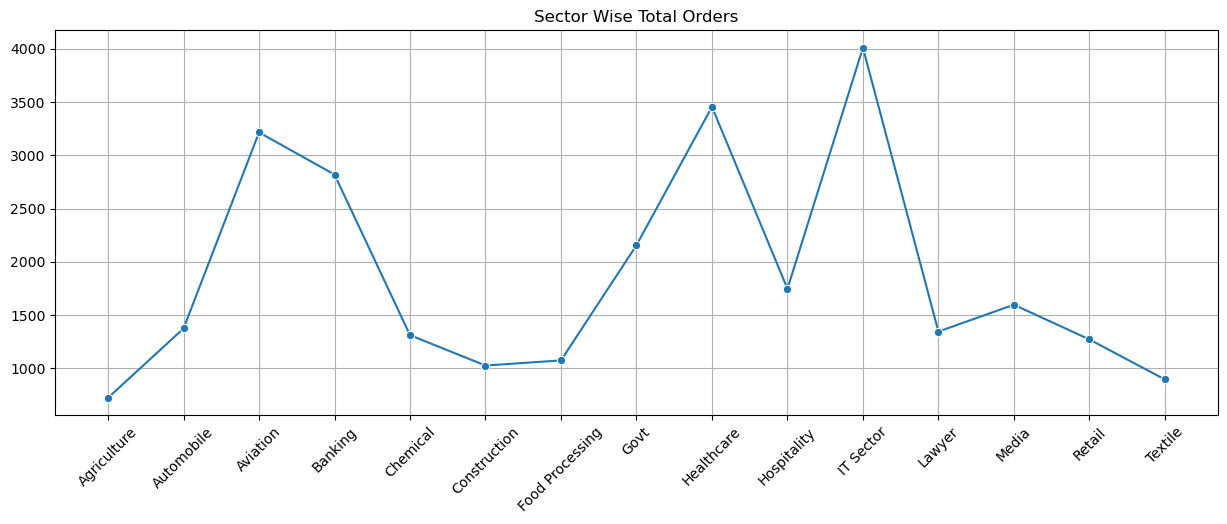

In [138]:
#Sector wise Orders line Chart
# Average Orders Line Plot
plt.figure(figsize=(15, 5))
sns.lineplot(x="Sector", y="Orders", data=df, errorbar=None, marker="o")
plt.title("Sector Wise Avg Orders")
plt.xlabel("")
plt.ylabel("")
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Total Orders Line Plot (Grouped)
T1 = df.groupby("Sector", as_index=False)["Orders"].sum()
plt.figure(figsize=(15, 5))
sns.lineplot(x="Sector", y="Orders", data=T1, marker="o")
plt.title("Sector Wise Total Orders")
plt.xlabel("")
plt.ylabel("")
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [139]:
# Check Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  object 
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Sector            11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(3), object(9)
memory usage: 1.1+ MB


# Zone wise Orders Total Amount

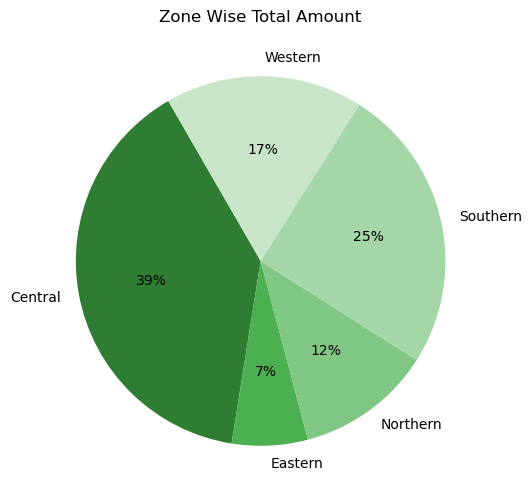

In [140]:
c2 = ['#C8E5C9', '#A5D6A7', '#81C784', '#4CAF50', '#2E7D32'][::-1]
T2 = df.groupby("Zone", as_index=False)["Amount"].sum()
plt.figure(figsize=(8, 6))
plt.pie(T2["Amount"], labels=T2["Zone"], autopct='%1.0f%%', startangle=120, colors=c2)
plt.title("Zone Wise Total Amount")
plt.show()

# Top 10 States Amount wise

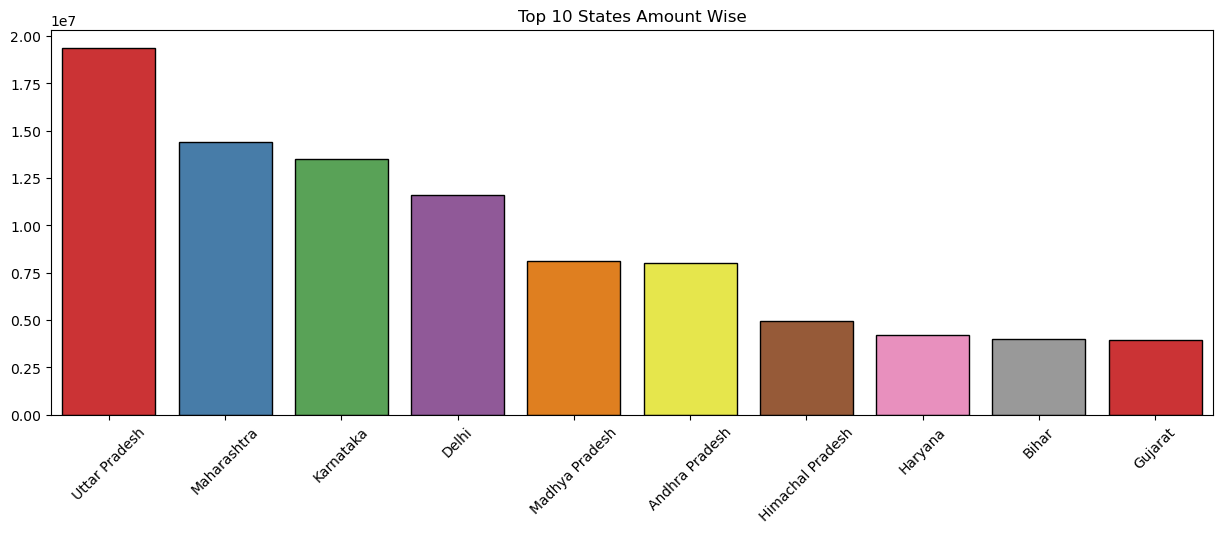

In [141]:
T3 = df.groupby("State", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False).head(10)
plt.figure(figsize=(15, 5))
sns.barplot(x="State", y="Amount", data=T3, palette="Set1", edgecolor="black")
plt.title("Top 10 States Amount Wise")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45)
plt.show()

# Sector Wise Total amount

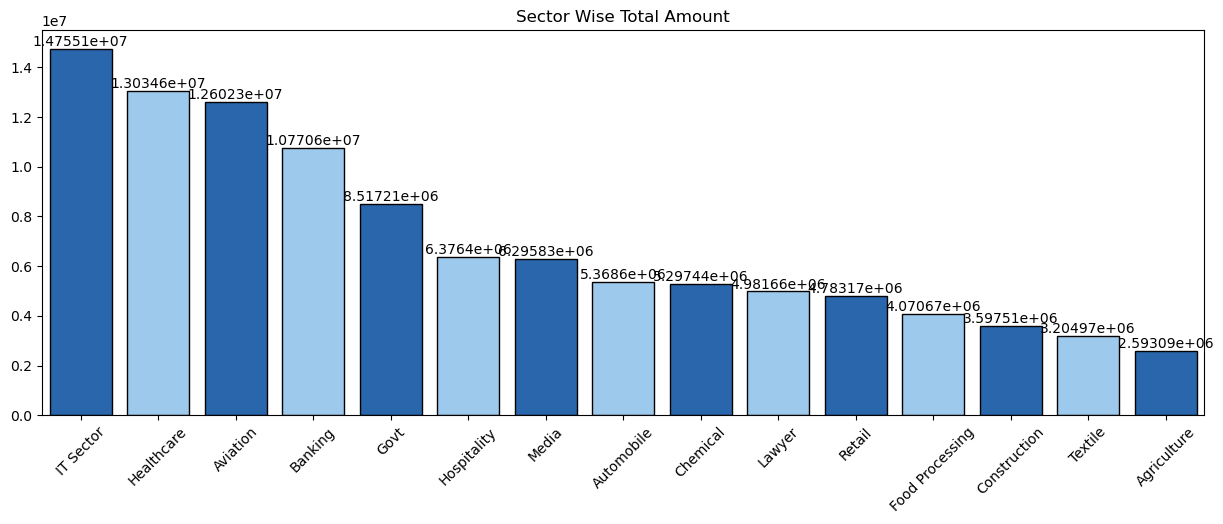

In [142]:
plt.figure(figsize=(15,5))

T4 = df.groupby("Sector", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False)

A1=sns.barplot(
    x="Sector",
    y="Amount",
    data=T4,
    palette=["#1565C0", "#90CAF9"],
    edgecolor="black"
)

plt.title("Sector Wise Total Amount")

plt.xlabel("")

plt.ylabel("")

plt.xticks(rotation=45)

for y in A1.containers:
    A1.bar_label(y)

plt.show()

# Product Category wise Orders

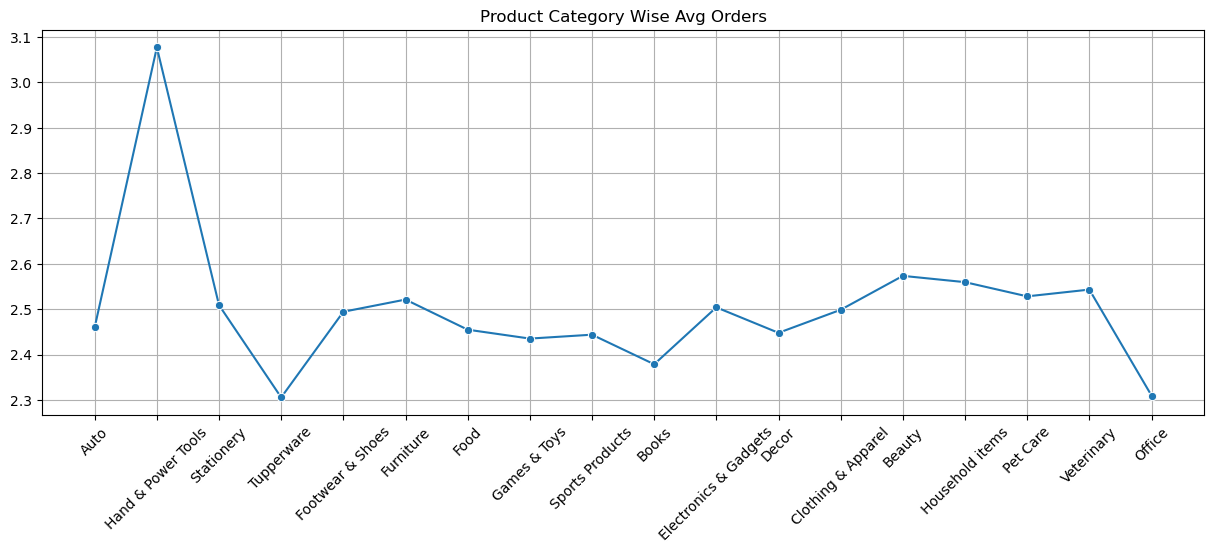

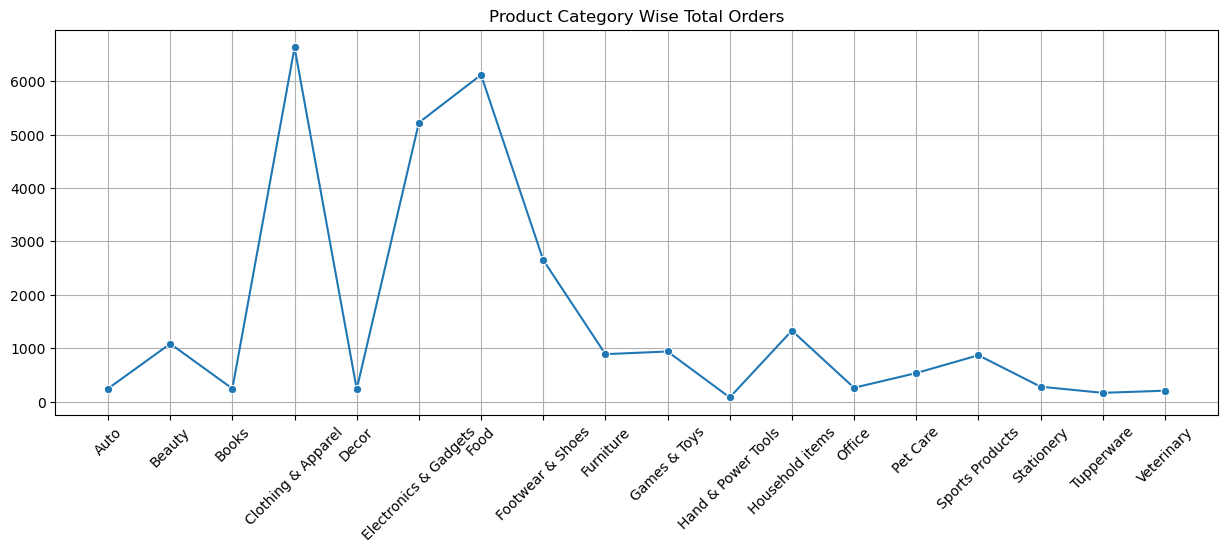

In [143]:
# Average Orders Line Plot
plt.figure(figsize=(15, 5))
sns.lineplot(x="Product_Category", y="Orders", data=df, ci=None, marker="o")
plt.title("Product Category Wise Avg Orders")
plt.xlabel("")
plt.ylabel("")
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Total Orders Line Plot (Grouped)
T1 = df.groupby("Product_Category", as_index=False)["Orders"].sum()
plt.figure(figsize=(15, 5))
sns.lineplot(x="Product_Category", y="Orders", data=T1, marker="o")
plt.title("Product Category Wise Total Orders")
plt.xlabel("")
plt.ylabel("")
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Marital Status Wise Total Amount

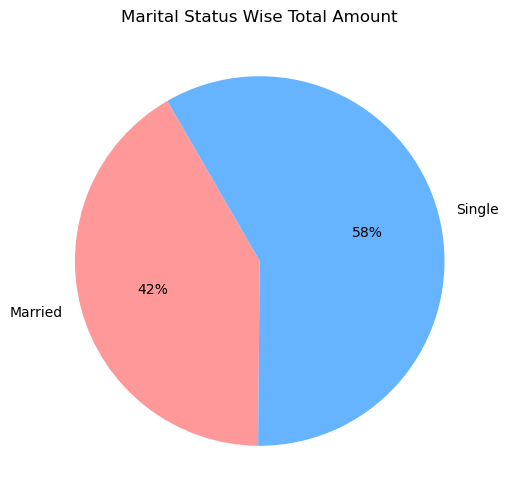

In [144]:
c2 = ['#FF9999', '#66B3FF']
T2 = df.groupby("Marital_Status", as_index=False)["Amount"].sum()
plt.figure(figsize=(8, 6))
plt.pie(T2["Amount"], labels=T2["Marital_Status"], autopct='%1.0f%%', startangle=120, colors=c2)
plt.title("Marital Status Wise Total Amount")
plt.show()

# Top 10 Product categories Amount wise

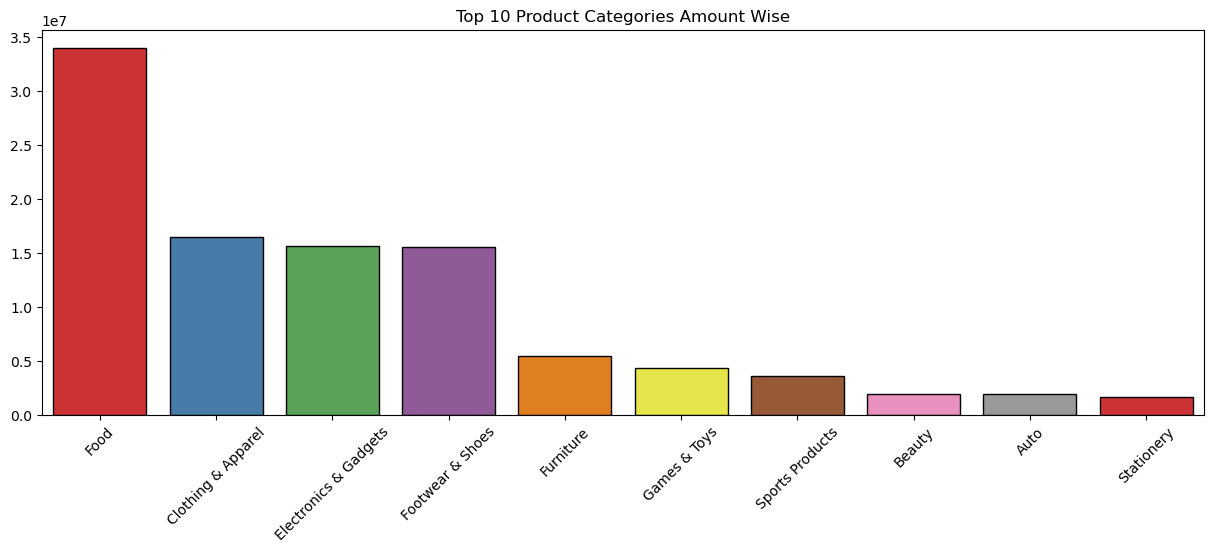

In [145]:
T3 = df.groupby("Product_Category", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False).head(10)
plt.figure(figsize=(15, 5))
sns.barplot(x="Product_Category", y="Amount", data=T3, palette="Set1", edgecolor="black")
plt.title("Top 10 Product Categories Amount Wise")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45)
plt.show()